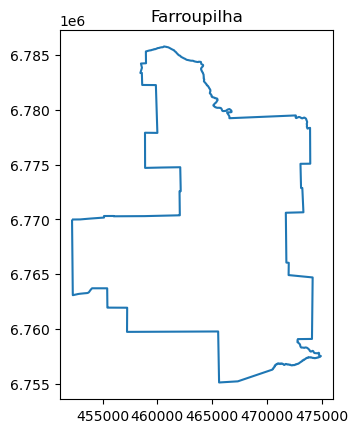

In [24]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

gdf_farroupilha = gpd.read_file('/home/jovyan/work/data/input/params/far/lim_munic/Limite_Municipal.shp')
gdf_farroupilha_urb = gpd.read_file('/home/jovyan/work/data/input/params/far/perimetro_urb/Perimetro_Urbano.shp')

gdf_farroupilha.plot()

plt.title("Farroupilha")

plt.show()

In [25]:
import os, sys
from pyspark.sql import SparkSession

sys.path.append(os.path.join(os.getcwd(), "/home/jovyan/work/src/pyspark_app"))

import session

spark = SparkSession.builder.getOrCreate()
url = session.jdbc_url()
props = session.jdbc_props()

table_name = "gps.stops"

df = spark.read.jdbc(
    url=url,
    table=table_name,
    properties=props
)

df_stops = df.toPandas()

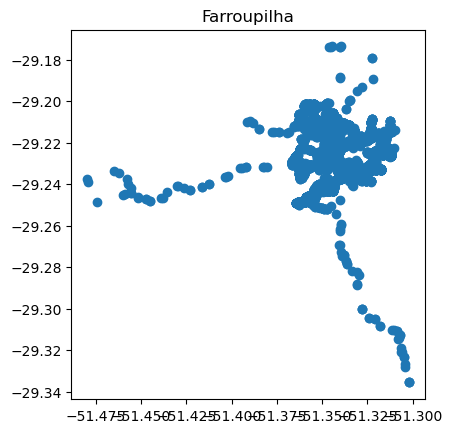

In [26]:
df_stops['geometry'] = df_stops.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

gdf_stops = gpd.GeoDataFrame(df_stops, geometry='geometry', crs="EPSG:4326")

gdf_stops.plot()

plt.title("Farroupilha")

plt.show()

<Axes: >

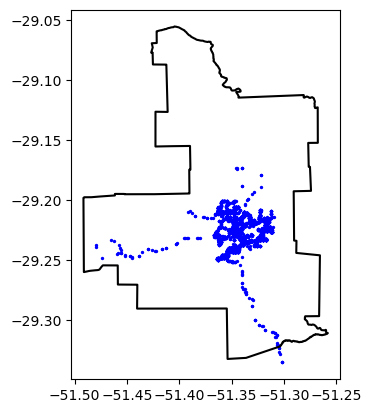

In [57]:
gdf_farroupilha = gdf_farroupilha.to_crs(gdf_stops.crs)

ax = gdf_farroupilha.plot(color='black', edgecolor='black')
gdf_stops.plot(ax=ax, color='blue', markersize=2)

In [56]:
gdf_stops = gpd.GeoDataFrame(
    df_stops,
    geometry=gpd.points_from_xy(df_stops['lon'], df_stops['lat']),
    crs="EPSG:4326"
)

poly = gdf_farroupilha.geometry.union_all()

gdf_stops['is_in_perimeter'] = gdf_stops.within(poly)

In [55]:
gdf_stops['is_in_perimeter']

counts = gdf_stops['is_in_perimeter'].value_counts(dropna=False)
print(counts)


is_in_perimeter
False    5101
Name: count, dtype: int64
